# Supercooled Profiles from MEOP Platform 9900109

In [31]:
import numpy as np
import pandas as pd
import xarray as xr
import scipy as sp
import mat73 # for loading .mat files version >= 7.3
from datetime import datetime, timedelta

# packages for plotting
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import cmocean.cm as cmo # ocean colormaps

# my own plotting functions
from obs_plotting_functions import *

## Load MEOP Data

In [32]:
filepath = "/isibhv/projects-noreplica/p_so-clim/alhaum001/supercool_profiles_merged_20200911.mat"
matstructs= mat73.loadmat(filepath) # this loads the matlab file as a python dictionary
matstructs.keys() # the dictionary keys (the names of the mat structures in the .mat file)

dict_keys(['data0', 'data1', 'data1_other', 'data2'])

In this Notebook, I look at supercooled MEOP / argofloat profiles from Haumann et al. (2020). The data is loaded from the file supercool_profiles_merged_20200911.mat. This file contains the following structures:
- data0: ?
- data1: metadata of the supercooled profiles
- data1_other: metadata of all profiles (or the non-supercooled?)
- data2: the supercooled profiles

In [33]:
data1 = matstructs['data1']
data1_other = matstructs['data1_other']
data2 = matstructs['data2']

### Add Datetime Variable to Data1 and Data1_other

In [34]:
# add datetime variable
matlab_zero_time = datetime(1,1,1) # Matlab's day zero is 0000-01-01, but Python's datetime starts at 0001-01-01, so we need to account for that when converting

# DATA1
days = data1["dates"]-1-366 # convert from Matlab's datenum to number of days since 0001-01-01, accounting for the fact that Matlab's datenum starts at 1 and includes a leap year in year 0
datetimes = [
    matlab_zero_time + timedelta(days=day) if day == day else float('nan') # convert to datetime, respecting NaN values
    for day in days
]

data1["datetimes"] = pd.Series(np.array(datetimes))

# DATA1_OTHER
days_other = data1_other["dates"]-1-366
datetimes_other = [
    matlab_zero_time + timedelta(days=day) if day == day else float('nan')
    for day in days_other
]

data1_other["datetimes"] = pd.Series(np.array(datetimes_other))


### Filter for Seal 9900109

In [52]:
mask_9900109 = (data1["id"] == 9900109)
data1_9900109 = {key: data1[key][mask_9900109] for key in data1.keys()}
data2_9900109 = {key: data2[key][:,mask_9900109] for key in data2.keys()}

mask_other_9900109 = (data1_other["id"] == 9900109)
data1_other_9900109 = {key: data1_other[key][mask_other_9900109] for key in data1_other.keys()}

print("Number of supercooled profiles: ", len(data1_9900109["datetimes"]))
print("Number of profiles without supercooling: ", len(data1_other_9900109["datetimes"]))
print(f"Ratio: {len(data1_9900109["datetimes"])/len(data1_other_9900109["datetimes"])*100:.0f} %")

Number of supercooled profiles:  209
Number of profiles without supercooling:  411
Ratio: 51 %


### Create Dataset of All Profiles from Seal 9900109 (both supercooled and not supercooled)

In [36]:
# make dataframe with all profiles of this seal, both supercooled and not supercooled

# create empty dataframe
data1_9900109_all_df = pd.DataFrame()

for key in data1_9900109.keys():
    if key in data1_other_9900109.keys(): # for variables that exist in both data1 and data1_other just concatenate
        data1_9900109_all_df[key] = np.concatenate([data1_9900109[key], data1_other_9900109[key]])
    else: # otherwise insert values from and then fill up with nan
        nan_filler = np.empty(411) * np.nan
        data1_9900109_all_df[key] = np.concatenate([data1_9900109[key], nan_filler])

# sort by dates
data1_9900109_all_df = data1_9900109_all_df.sort_values("dates")

# crop to june-november
mask_time = data1_9900109_all_df.datetimes > datetime(2008,6,1)
data1_9900109_all_df = data1_9900109_all_df.loc[mask_time, :]
data1_9900109_all_df 

,bath,bot,bot_ps,cycle,dates,dcycle,ddates,f,flag,heat_ps,...,max_ps,max_ps_dpth,mld,pycno,seaice_iceshelf,surf,surf_ps,thickn_ps,types,datetimes
444,NaN,NaN,NaN,283.0,733560.152778,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,2008-06-01 03:39:59.999998
445,NaN,NaN,NaN,284.0,733560.569444,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,2008-06-01 13:40:00.000004
446,NaN,NaN,NaN,285.0,733560.812500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,2008-06-01 19:30:00.000000
447,NaN,NaN,NaN,286.0,733561.055556,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,2008-06-02 01:19:59.999996
448,NaN,NaN,NaN,287.0,733561.354167,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,2008-06-02 08:29:59.999997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204,4065.00,561.939812,105.976221,717.0,733740.791667,NaN,NaN,-0.000124,0.0,-9.398842e+06,...,-0.064374,98.054667,55.471050,93.598658,5.0,5.944048,60.423089,45.553132,3.0,2008-11-28 18:59:59.999997
205,4393.25,494.741718,NaN,718.0,733741.222222,NaN,NaN,-0.000125,0.0,-3.145837e+06,...,-0.016071,47.547104,55.470544,65.869594,0.0,5.943994,NaN,NaN,3.0,2008-11-29 05:20:00.000002
206,4065.25,494.742827,51.508978,719.0,733741.298611,NaN,NaN,-0.000125,0.0,-5.302087e+06,...,-0.024705,18.822095,55.470669,65.869741,1.0,5.944007,5.944007,45.564971,3.0,2008-11-29 07:10:00.000001
207,4306.75,579.723695,NaN,720.0,733741.569444,NaN,NaN,-0.000124,0.0,-5.074807e+05,...,-0.006914,17.831655,35.661753,53.985508,0.0,5.944058,NaN,NaN,3.0,2008-11-29 13:40:00.000004


## Load ERA5 Data

In [105]:
c_max = 0.99
filename = "ERA5_seaice_netHeat_leadHeat_cmax"+str(c_max)+".nc"
df_seaice = xr.open_dataset(filename)

# aggregate to daily means
df_seaice_daily = df_seaice.resample(time='D').mean(skipna=True)

# only 2008 data
df_seaice_2008 = df_seaice.sel(time=slice("2008-01-01", "2008-12-31"))

sh: getfattr: command not found


In [8]:
# sea ice animation
make_animation = False
if make_anmiation:
    fig = surface_animation(df_seaice_2008, "siconc", "ERA5", "time", "longitude", "latitude", "ice")
    fig.write_html("animation.html")

## Map View

### Max Pot SC

In [7]:
data1_other.keys()

dict_keys(['cycle', 'dates', 'id', 'id2', 'lat', 'lon', 'types', 'datetimes'])

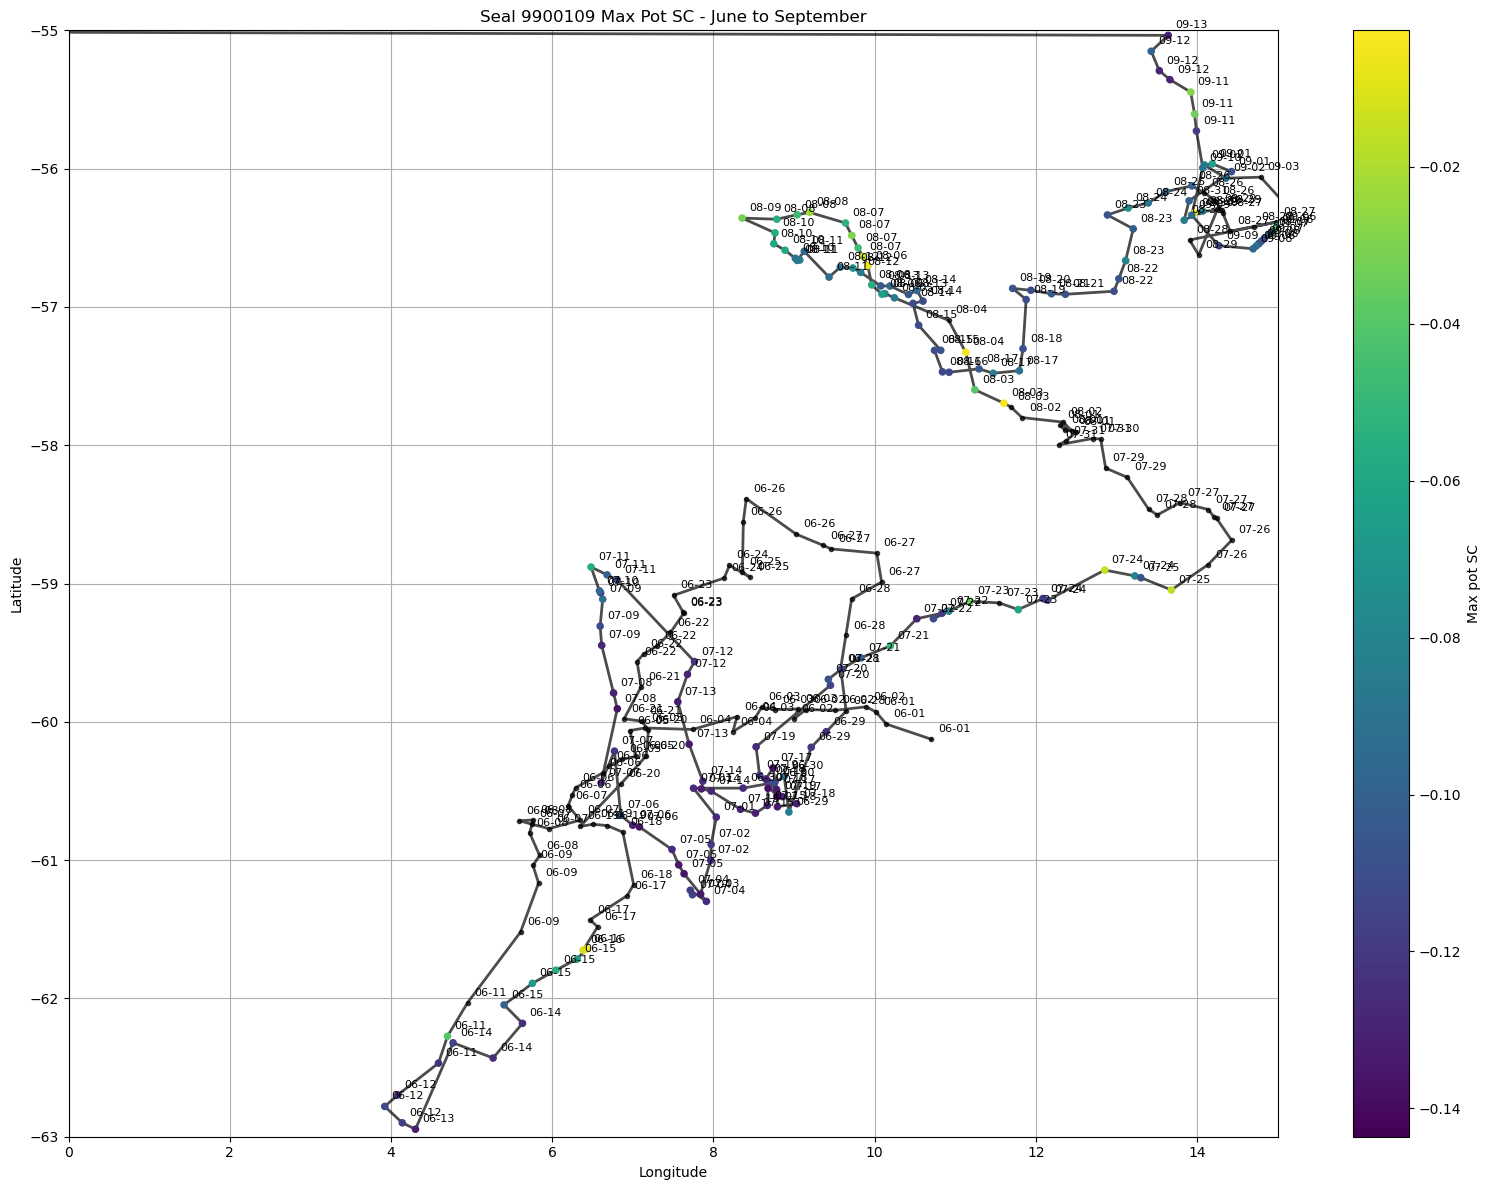

In [11]:
# MOVEMENT OF SEAL WITH MAX POT SC

# Plot
plt.figure(figsize=(16, 12))

# Draw the path line
plt.plot(data1_9900109_all_df['lon'], data1_9900109_all_df['lat'], '.-', linewidth=2, alpha=0.7, label='Movement Path', color = "black")


# Add scatter points with SC coloring
scatter = plt.scatter(data1_9900109_all_df['lon'], data1_9900109_all_df['lat'], c=data1_9900109_all_df["max_ps"], cmap='viridis', 
                      s=30, edgecolors='none', zorder=3, label='Locations')


# Apply the formatter to the colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Max pot SC')

# Annotate points with time
for i, row in data1_9900109_all_df.iterrows():
    plt.annotate(row['datetimes'].strftime('%m-%d'), (row['lon'], row['lat']), 
                 textcoords="offset points", xytext=(5,5), ha='left', fontsize=8, zorder=4)

# Label axes
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Seal 9900109 Max Pot SC - June to September')

plt.xlim(0,15)
plt.ylim(-63,-55)

plt.grid(True)
plt.tight_layout()
plt.show()

### Max SC Depth

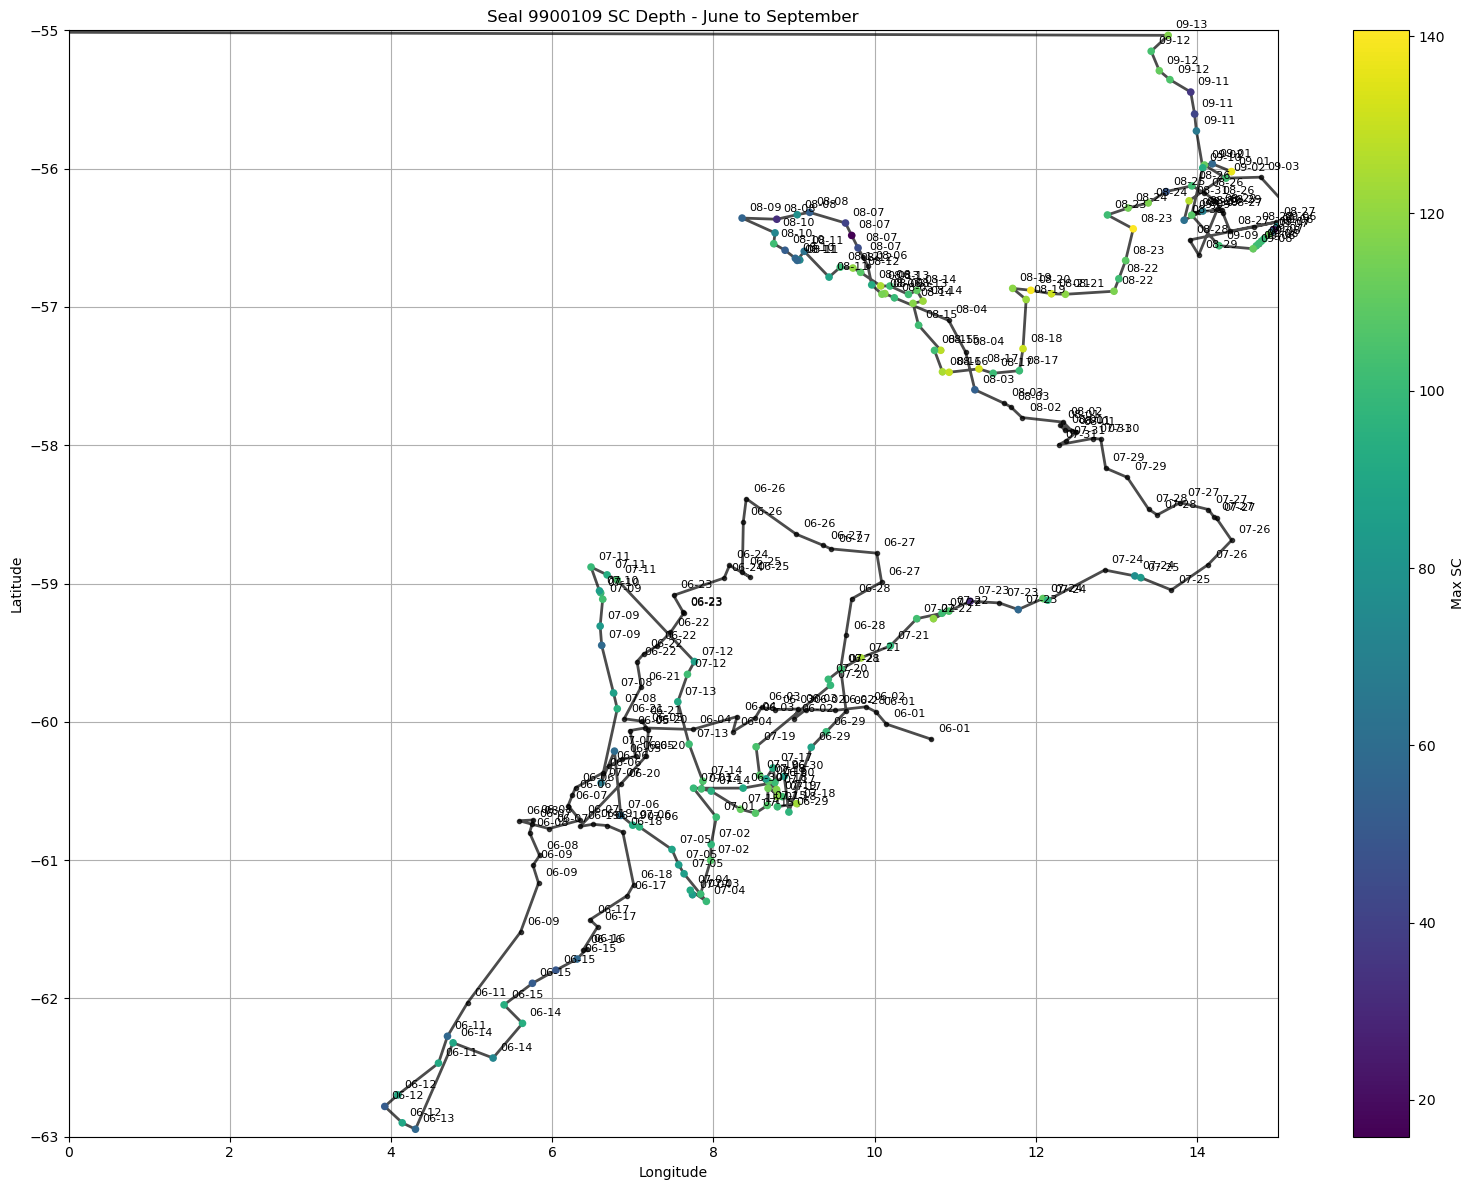

In [9]:
# MOVEMENT OF SEAL WITH MAX POT SC

# Plot
plt.figure(figsize=(16, 12))

# Draw the path line
plt.plot(data1_9900109_all_df['lon'], data1_9900109_all_df['lat'], '.-', linewidth=2, alpha=0.7, label='Movement Path', color = "black")


# Add scatter points with SC coloring
scatter = plt.scatter(data1_9900109_all_df['lon'], data1_9900109_all_df['lat'], c=data1_9900109_all_df["bot_ps"], cmap='viridis', 
                      s=30, edgecolors='none', zorder=3, label='Locations')


# Apply the formatter to the colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Max SC')

# Annotate points with time
for i, row in data1_9900109_all_df.iterrows():
    plt.annotate(row['datetimes'].strftime('%m-%d'), (row['lon'], row['lat']), 
                 textcoords="offset points", xytext=(5,5), ha='left', fontsize=8, zorder=4)

# Label axes
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Seal 9900109 SC Depth - June to September')

plt.xlim(0,15)
plt.ylim(-63,-55)

plt.grid(True)
plt.tight_layout()
plt.show()

### MLD Penetration

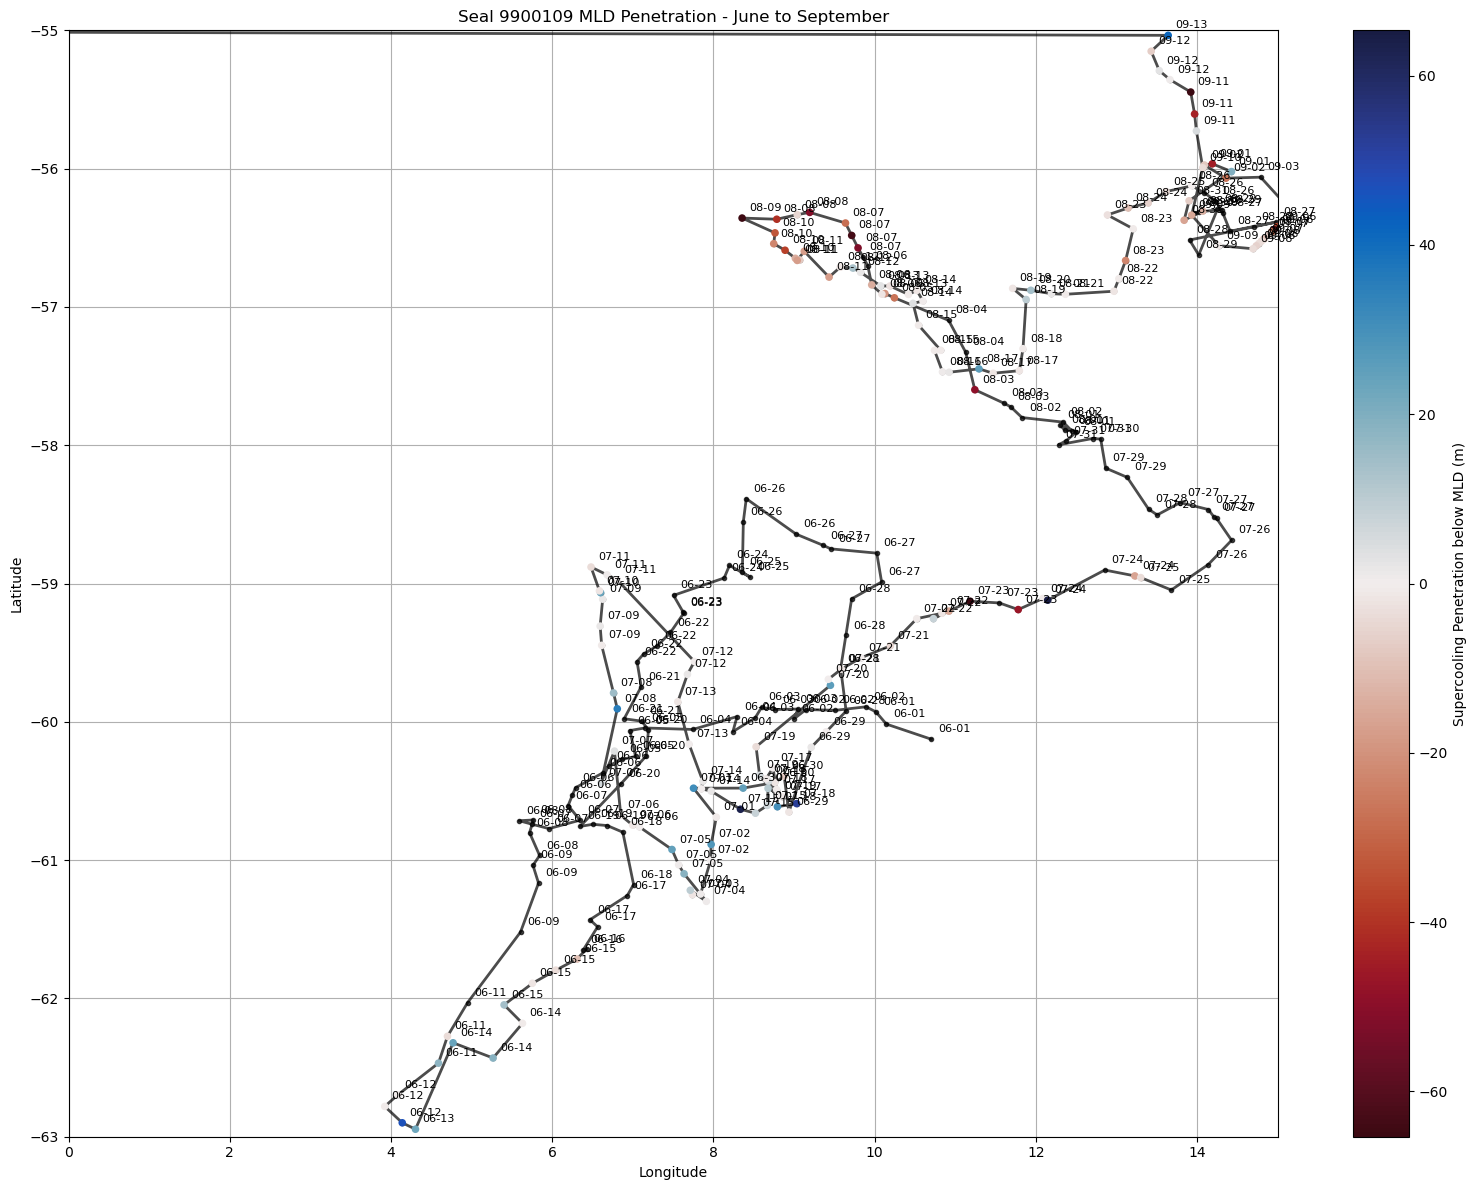

In [13]:
# MOVEMENT OF SEAL WITH MAX POT SC

# Plot
plt.figure(figsize=(16, 12))

# Draw the path line
plt.plot(data1_9900109_all_df['lon'], data1_9900109_all_df['lat'], '.-', linewidth=2, alpha=0.7, label='Movement Path', color = "black")


# Add scatter points with SC coloring
mld_penetration = data1_9900109_all_df["bot_ps"] - data1_9900109_all_df["mld"]
max_mld_pen = np.nanmax(mld_penetration)

scatter = plt.scatter(data1_9900109_all_df['lon'], data1_9900109_all_df['lat'], c = mld_penetration, cmap=cmo.balance.reversed(), vmin = -max_mld_pen, vmax = max_mld_pen,
                      s=30, edgecolors='none', zorder=3, label='Locations')


# Apply the formatter to the colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Supercooling Penetration below MLD (m)')

# Annotate points with time
for i, row in data1_9900109_all_df.iterrows():
    plt.annotate(row['datetimes'].strftime('%m-%d'), (row['lon'], row['lat']), 
                 textcoords="offset points", xytext=(5,5), ha='left', fontsize=8, zorder=4)

# Label axes
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Seal 9900109 MLD Penetration - June to September')

plt.xlim(0,15)
plt.ylim(-63,-55)

plt.grid(True)
plt.tight_layout()
plt.show()

## July Cluster 06-29 to 07-18

In [106]:
# daily sea ice concentration in this cluster
df_seaice_cluster07 = df_seaice_daily.sel(time=slice("2008-06-29", "2008-07-18"))
fig = surface_animation(df_seaice_cluster07, "siconc", "ERA5", "time", "longitude", "latitude", "ice")
fig.write_html("seaice_animation_cluster07.html")
# cluster average
df_seaice_cluster07_mean = df_seaice_cluster07.mean("time")

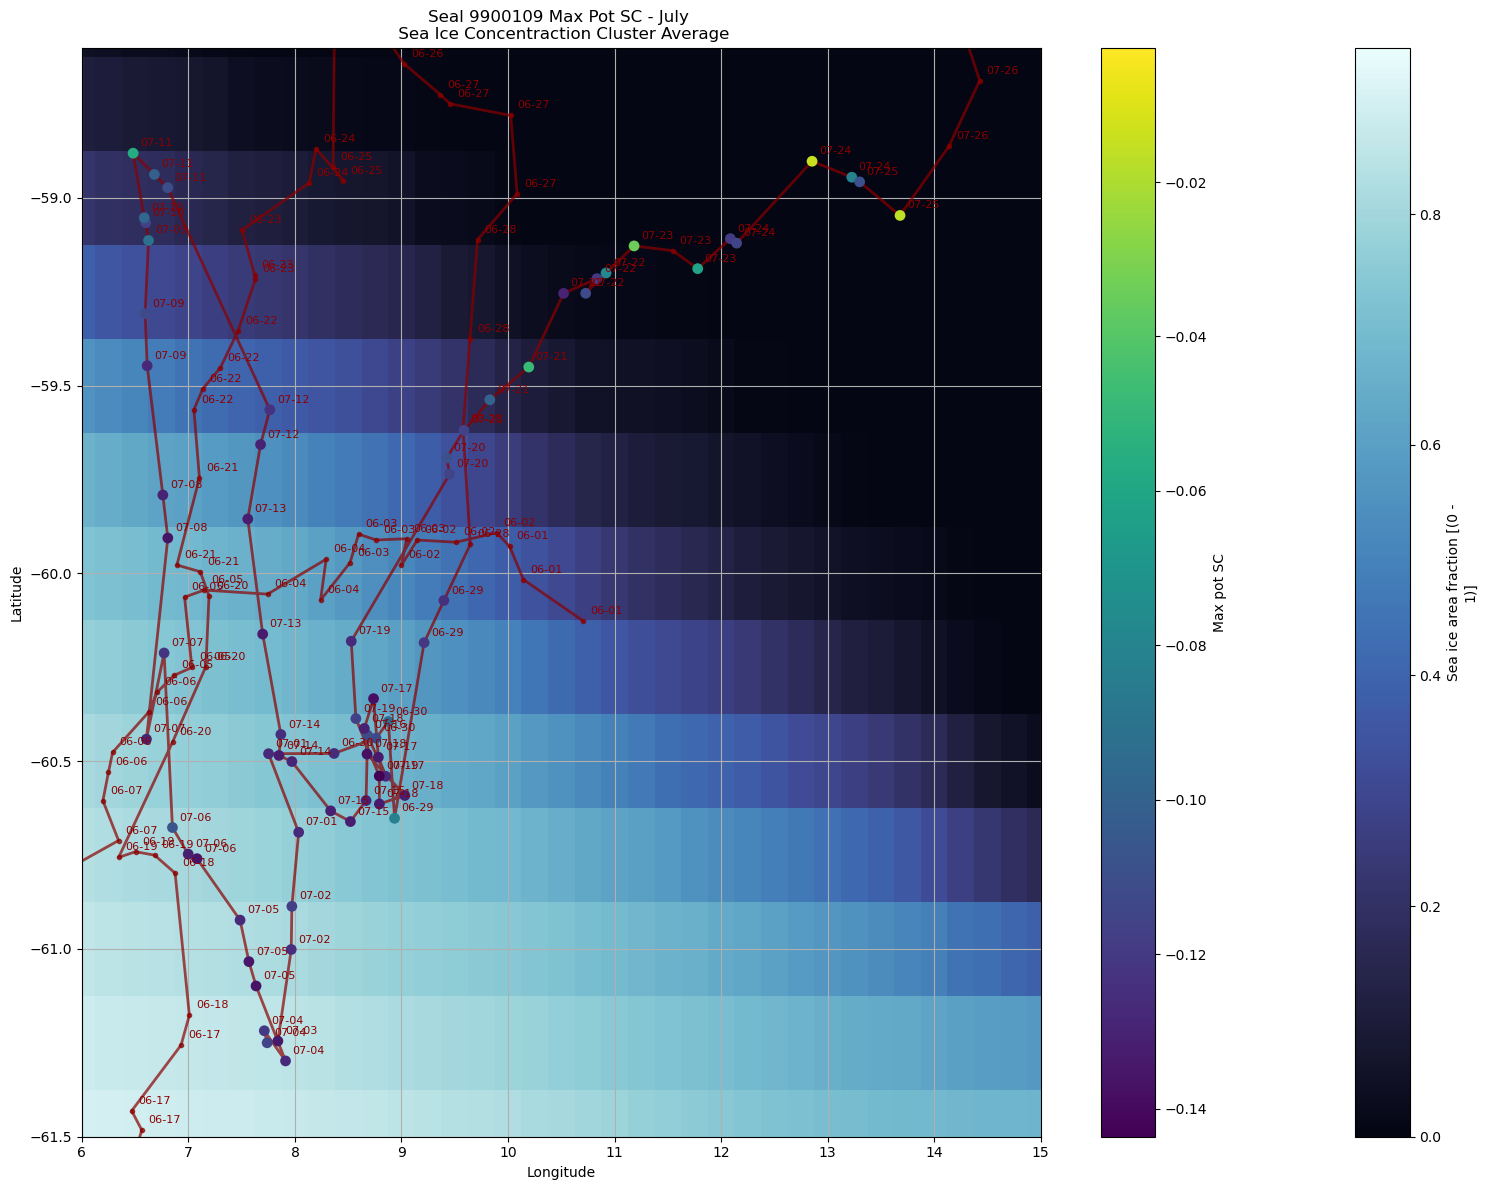

In [131]:
# MOVEMENT OF SEAL WITH MAX POT SC

# Plot
plt.figure(figsize=(16, 12))

# plot sea ice concentration
df_seaice_cluster07_mean.siconc.plot(cmap = cmo.ice)

# Draw the path line
plt.plot(data1_9900109_all_df['lon'], data1_9900109_all_df['lat'], '.-', linewidth=2, alpha=0.7, label='Movement Path', color = "darkred")


# Add scatter points with SC coloring
scatter = plt.scatter(data1_9900109_all_df['lon'], data1_9900109_all_df['lat'], c=data1_9900109_all_df["max_ps"], cmap='viridis', 
                      s=60, edgecolors='none', zorder=3, label='Locations')


# Apply the formatter to the colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Max pot SC')

# Annotate points with time
for i, row in data1_9900109_all_df.iterrows():
    plt.annotate(row['datetimes'].strftime('%m-%d'), (row['lon'], row['lat']), 
                 textcoords="offset points", xytext=(5,5), ha='left', fontsize=8, zorder=4, color = "darkred")

# Label axes
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Seal 9900109 Max Pot SC - July \n Sea Ice Concentraction Cluster Average')

plt.xlim(6,15)
plt.ylim(-61.5, -58.6)

plt.grid(True)
plt.tight_layout()
plt.show()

In [99]:
start = datetime(2008, 6, 29)
end = datetime(2008, 7, 18)

mask_9900109 = (data1["id"] == 9900109)
mask_time = (data1["datetimes"] < end) & (data1["datetimes"] > start)
mask_final = mask_9900109 & mask_time

cluster07_data1 = {key: data1[key][mask_final] for key in data1.keys()}
cluster07_data2 = {key: data2[key][:,mask_final] for key in data2.keys()}
cluster07_data2_datetimes = data1["datetimes"][mask_final]

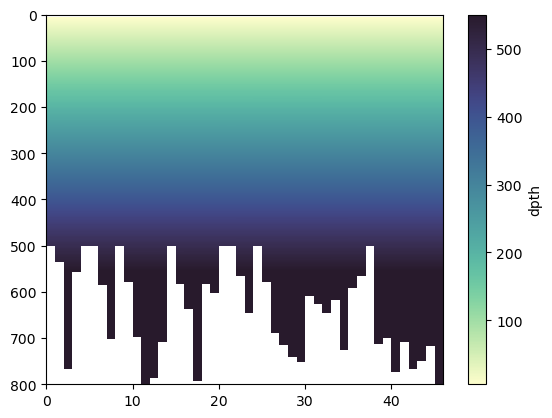

In [100]:
fig, ax = plt.subplots()

pcm = ax.pcolormesh(cluster07_data2["dpth"], vmax = 550, cmap = cmo.deep)

# ax.pcolormesh(cluster_data2_datetimes, cluster_data2["dpth"], cluster_data2["def_pt0"])

ax.set_ylim(800,0)

# make colorbar
fig.colorbar(pcm, label = "dpth")

/tmp/ipykernel_1446065/2019154800.py:7: UserWarning:

The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.

/tmp/ipykernel_1446065/2019154800.py:13: UserWarning:

The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.



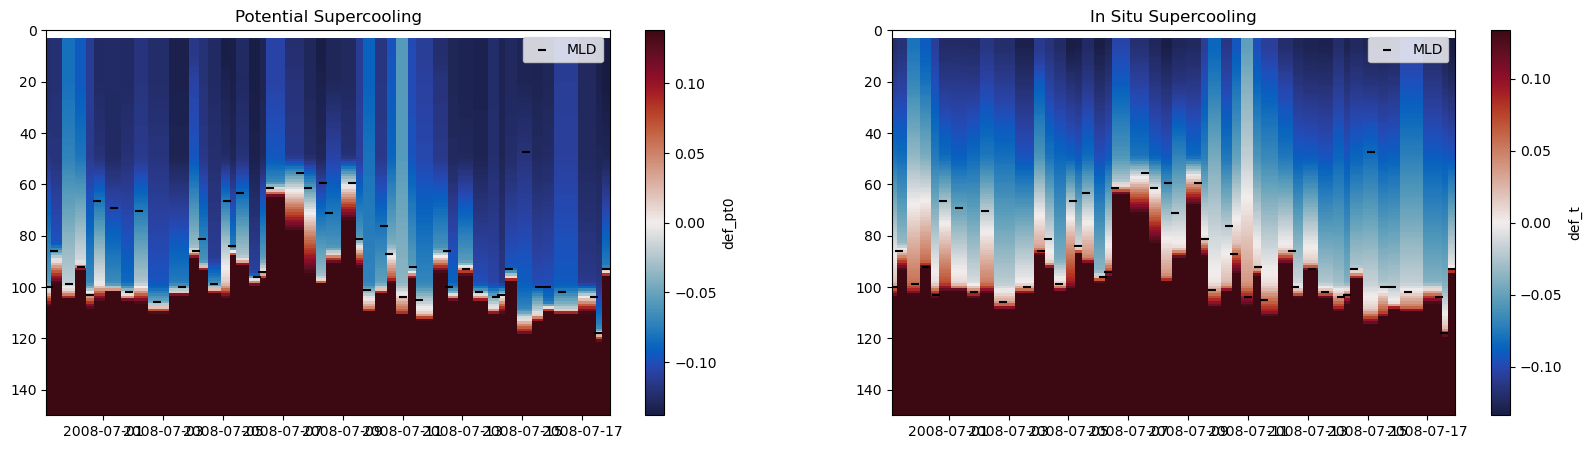

In [101]:
fig, ax = plt.subplots(1,2, figsize = (20,5))

depth = np.nan_to_num(cluster07_data2["dpth"], nan = 0)

# plot potential SC
max_SC = np.nanmin(cluster07_data2["def_pt0"])
pcm = ax[0].pcolormesh(cluster07_data2_datetimes, depth, cluster07_data2["def_pt0"], cmap = cmo.balance, vmin = max_SC, vmax = -max_SC)
# add MLD
ax[0].scatter(cluster07_data1["datetimes"], cluster07_data1["mld"], marker = "_", color = "black", label = "MLD")

# plot in situ SC
max_SC = np.nanmin(cluster07_data2["def_t"])
pcm_iS = ax[1].pcolormesh(cluster07_data2_datetimes, depth, cluster07_data2["def_t"], cmap = cmo.balance, vmin = max_SC, vmax = -max_SC)
# add MLD
ax[1].scatter(cluster07_data1["datetimes"], cluster07_data1["mld"], marker = "_", color = "black", label = "MLD")

ax[0].set_ylim(150,0)
ax[1].set_ylim(150,0)

ax[0].set_title("Potential Supercooling")
ax[1].set_title("In Situ Supercooling")

ax[0].legend(loc = "upper right")
ax[1].legend(loc = "upper right")

# make colorbar
fig.colorbar(pcm, label = "def_pt0")
fig.colorbar(pcm_iS, label = "def_t")


## August Cluster 08-13 to 08-14

In [139]:
# daily sea ice concentration in this cluster
df_seaice_cluster08 = df_seaice_daily.sel(time=slice("2008-08-13", "2008-08-14"))
fig = surface_animation(df_seaice_cluster08, "siconc", "ERA5", "time", "longitude", "latitude", "ice")
fig.write_html("seaice_animation_cluster08.html")
# cluster average
df_seaice_cluster08_mean = df_seaice_cluster08.mean("time")

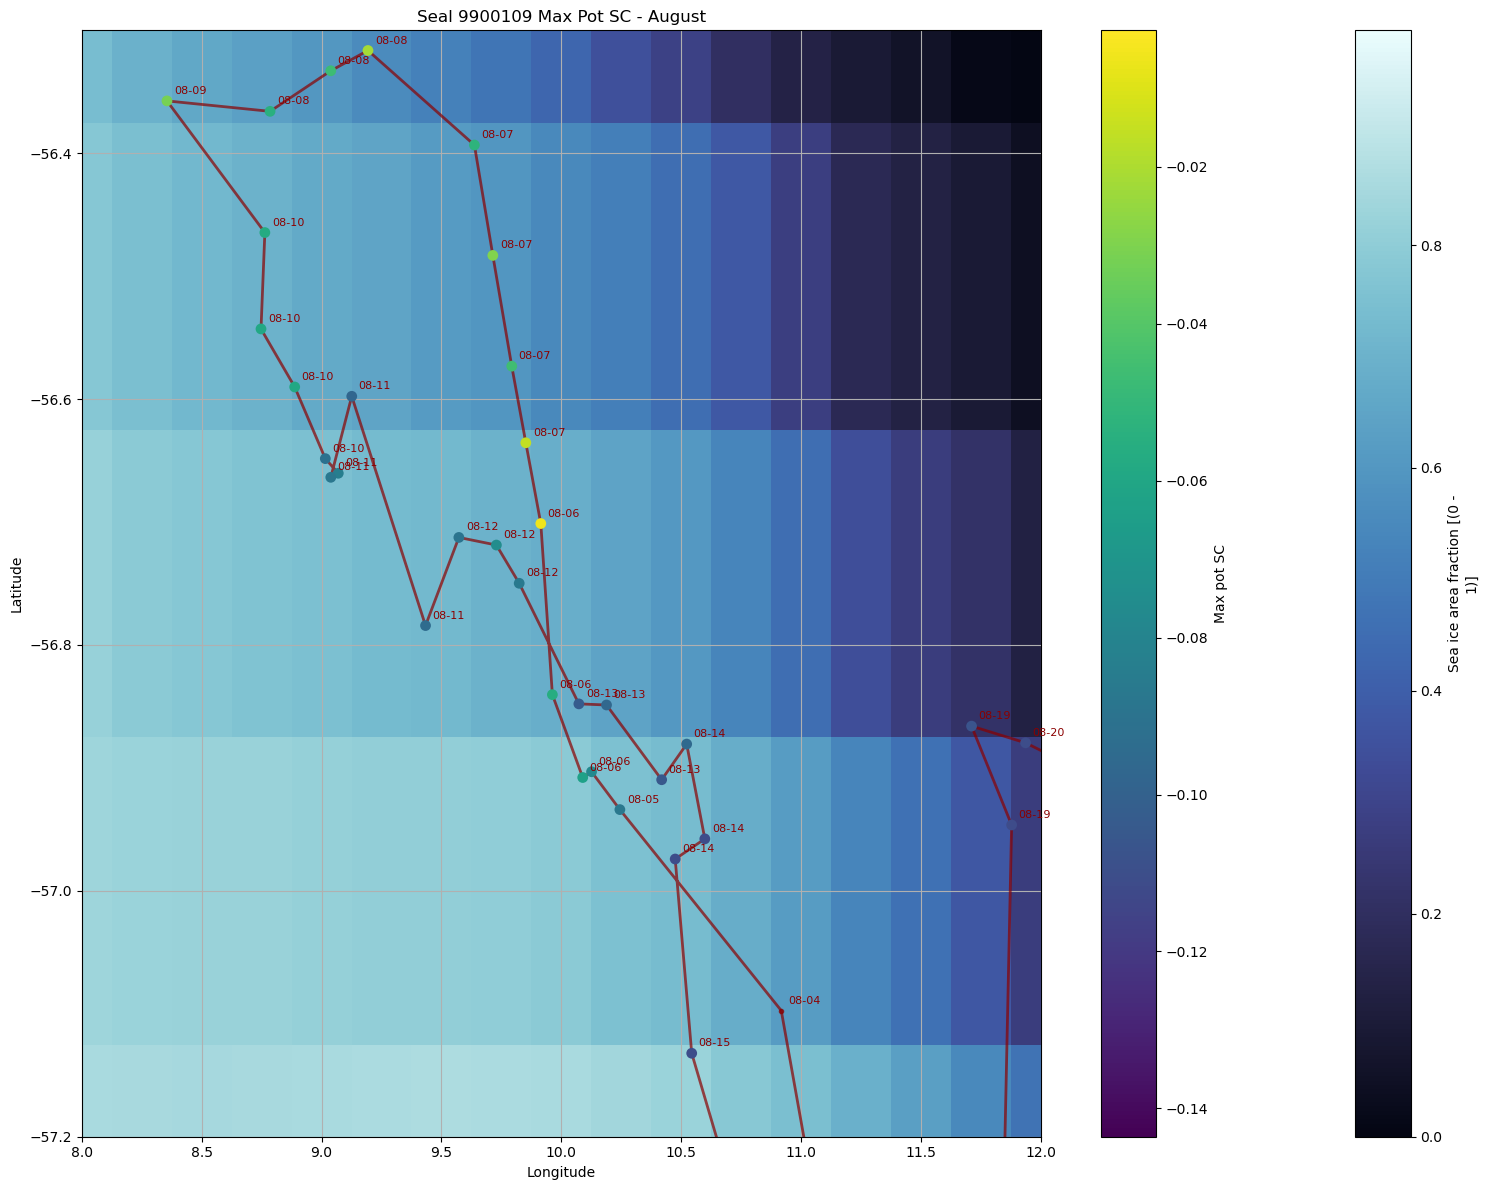

In [133]:
# MOVEMENT OF SEAL WITH MAX POT SC

# Plot
plt.figure(figsize=(16, 12))

# plot sea ice concentration
df_seaice_cluster08_mean.siconc.plot(cmap = cmo.ice)

# Draw the path line
plt.plot(data1_9900109_all_df['lon'], data1_9900109_all_df['lat'], '.-', linewidth=2, alpha=0.7, label='Movement Path', color = "darkred")


# Add scatter points with SC coloring
scatter = plt.scatter(data1_9900109_all_df['lon'], data1_9900109_all_df['lat'], c=data1_9900109_all_df["max_ps"], cmap='viridis', 
                      s=60, edgecolors='none', zorder=3, label='Locations')


# Apply the formatter to the colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Max pot SC')

# Annotate points with time
for i, row in data1_9900109_all_df.iterrows():
    plt.annotate(row['datetimes'].strftime('%m-%d'), (row['lon'], row['lat']), 
                 textcoords="offset points", xytext=(5,5), ha='left', fontsize=8, zorder=4, color = "darkred")

# Label axes
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Seal 9900109 Max Pot SC - August')

plt.xlim(8,12)
plt.ylim(-57.2,-56.3)

plt.grid(True)
plt.tight_layout()
plt.show()

In [94]:
start = datetime(2008, 8, 13)
end = datetime(2008, 8, 15)

mask_9900109 = (data1["id"] == 9900109)
mask_time = (data1["datetimes"] < end) & (data1["datetimes"] > start)
mask_final = mask_9900109 & mask_time

cluster08_data1 = {key: data1[key][mask_final] for key in data1.keys()}
cluster08_data2 = {key: data2[key][:,mask_final] for key in data2.keys()}
cluster08_data2_datetimes = data1["datetimes"][mask_final]

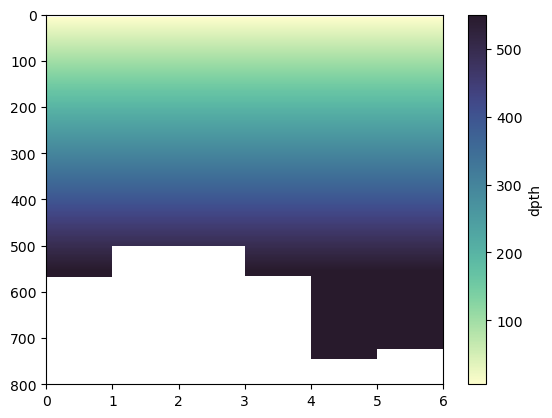

In [95]:
fig, ax = plt.subplots()

pcm = ax.pcolormesh(cluster08_data2["dpth"], vmax = 550, cmap = cmo.deep)

# ax.pcolormesh(cluster_data2_datetimes, cluster_data2["dpth"], cluster_data2["def_pt0"])

ax.set_ylim(800,0)

# make colorbar
fig.colorbar(pcm, label = "dpth")

/tmp/ipykernel_1446065/22915145.py:7: UserWarning:

The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.

/tmp/ipykernel_1446065/22915145.py:13: UserWarning:

The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.



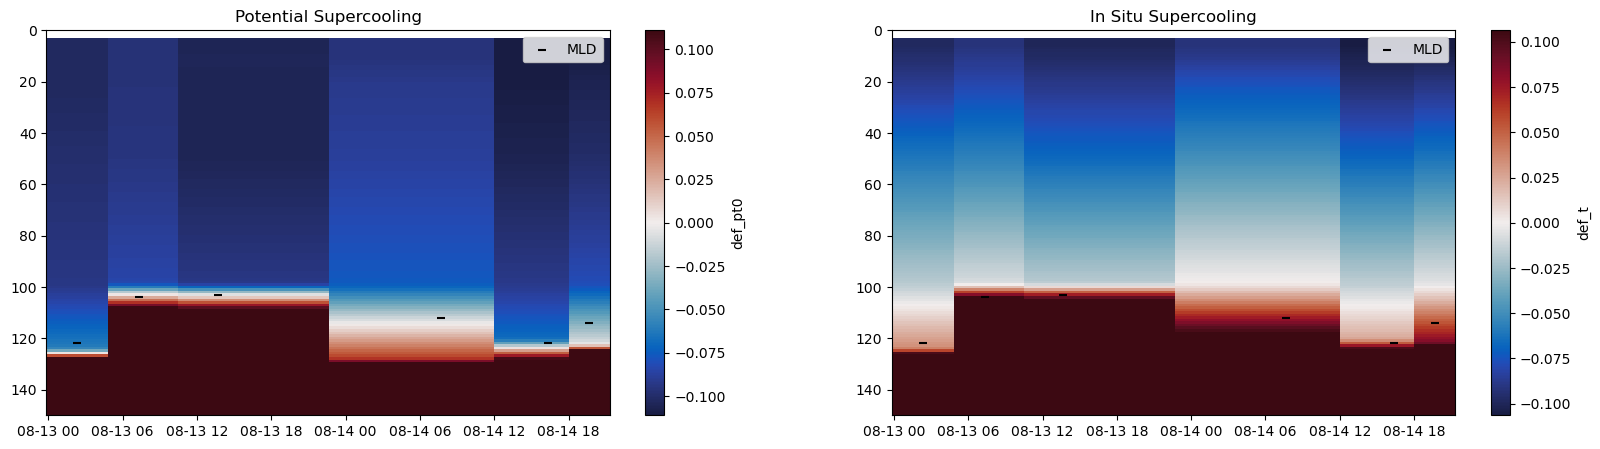

In [96]:
fig, ax = plt.subplots(1,2, figsize = (20,5))

depth = np.nan_to_num(cluster08_data2["dpth"], nan = 0)

# plot potential SC
max_SC = np.nanmin(cluster08_data2["def_pt0"])
pcm = ax[0].pcolormesh(cluster08_data2_datetimes, depth, cluster08_data2["def_pt0"], cmap = cmo.balance, vmin = max_SC, vmax = -max_SC)
# add MLD
ax[0].scatter(cluster08_data1["datetimes"], cluster08_data1["mld"], marker = "_", color = "black", label = "MLD")

# plot in situ SC
max_SC = np.nanmin(cluster08_data2["def_t"])
pcm_iS = ax[1].pcolormesh(cluster08_data2_datetimes, depth, cluster08_data2["def_t"], cmap = cmo.balance, vmin = max_SC, vmax = -max_SC)
# add MLD
ax[1].scatter(cluster08_data1["datetimes"], cluster08_data1["mld"], marker = "_", color = "black", label = "MLD")

ax[0].set_ylim(150,0)
ax[1].set_ylim(150,0)

ax[0].set_title("Potential Supercooling")
ax[1].set_title("In Situ Supercooling")

ax[0].legend(loc = "upper right")
ax[1].legend(loc = "upper right")

# make colorbar
fig.colorbar(pcm, label = "def_pt0")
fig.colorbar(pcm_iS, label = "def_t")


/tmp/ipykernel_1446065/3162692060.py:5: UserWarning:

The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.



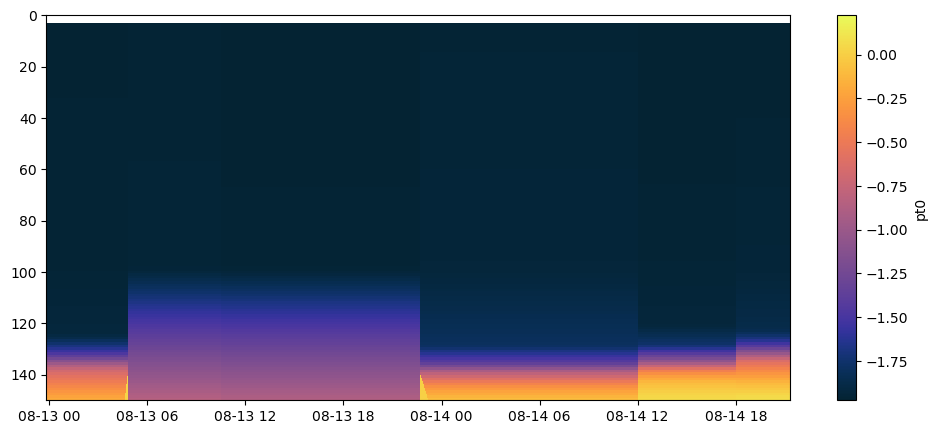

In [97]:
fig, ax = plt.subplots(figsize = (12,5))

depth = np.nan_to_num(cluster08_data2["dpth"], nan = 0)

pcm = ax.pcolormesh(cluster08_data2_datetimes, depth, cluster08_data2["pt0"], cmap = cmo.thermal)

ax.set_ylim(150,0)

# make colorbar
fig.colorbar(pcm, label = "pt0")

## September Cluster 09-04 to 09-08

In [138]:
# daily sea ice concentration in this cluster
df_seaice_cluster09 = df_seaice_daily.sel(time=slice("2008-09-04", "2008-09-08"))
fig = surface_animation(df_seaice_cluster09, "siconc", "ERA5", "time", "longitude", "latitude", "ice")
fig.write_html("seaice_animation_cluster09.html")
# cluster average
df_seaice_cluster09_mean = df_seaice_cluster09.mean("time")

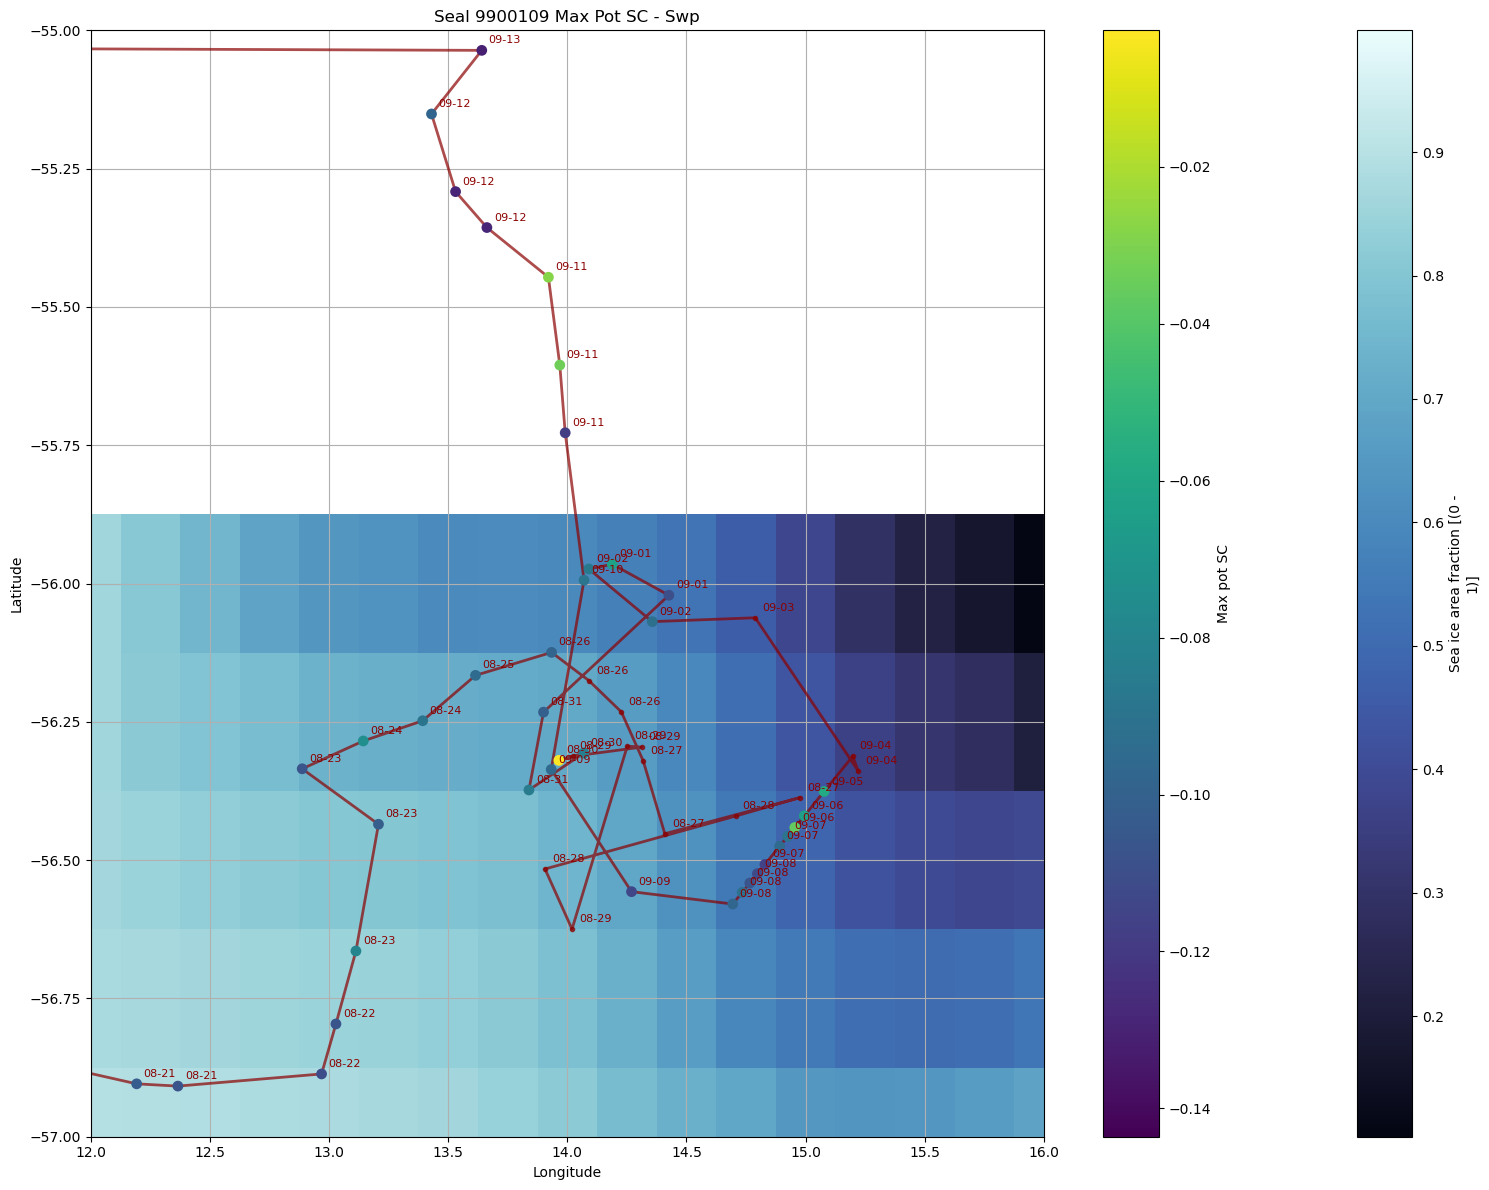

In [137]:
# MOVEMENT OF SEAL WITH MAX POT SC

# Plot
plt.figure(figsize=(16, 12))

# plot sea ice concentration
df_seaice_cluster09_mean.siconc.plot(cmap = cmo.ice)

# Draw the path line
plt.plot(data1_9900109_all_df['lon'], data1_9900109_all_df['lat'], '.-', linewidth=2, alpha=0.7, label='Movement Path', color = "darkred")


# Add scatter points with SC coloring
scatter = plt.scatter(data1_9900109_all_df['lon'], data1_9900109_all_df['lat'], c=data1_9900109_all_df["max_ps"], cmap='viridis', 
                      s=60, edgecolors='none', zorder=3, label='Locations')


# Apply the formatter to the colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Max pot SC')

# Annotate points with time
for i, row in data1_9900109_all_df.iterrows():
    plt.annotate(row['datetimes'].strftime('%m-%d'), (row['lon'], row['lat']), 
                 textcoords="offset points", xytext=(5,5), ha='left', fontsize=8, zorder=4, color = "darkred")

# Label axes
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Seal 9900109 Max Pot SC - Swp')

plt.xlim(12,16)
plt.ylim(-57,-55)

plt.grid(True)
plt.tight_layout()
plt.show()

In [91]:
start = datetime(2008, 9, 4)
end = datetime(2008, 9, 8)

mask_9900109 = (data1["id"] == 9900109)
mask_time = (data1["datetimes"] < end) & (data1["datetimes"] > start)
mask_final = mask_9900109 & mask_time

cluster09_data1 = {key: data1[key][mask_final] for key in data1.keys()}
cluster09_data2 = {key: data2[key][:,mask_final] for key in data2.keys()}
cluster09_data2_datetimes = data1["datetimes"][mask_final]

/tmp/ipykernel_1446065/4246599511.py:7: UserWarning:

The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.

/tmp/ipykernel_1446065/4246599511.py:13: UserWarning:

The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.



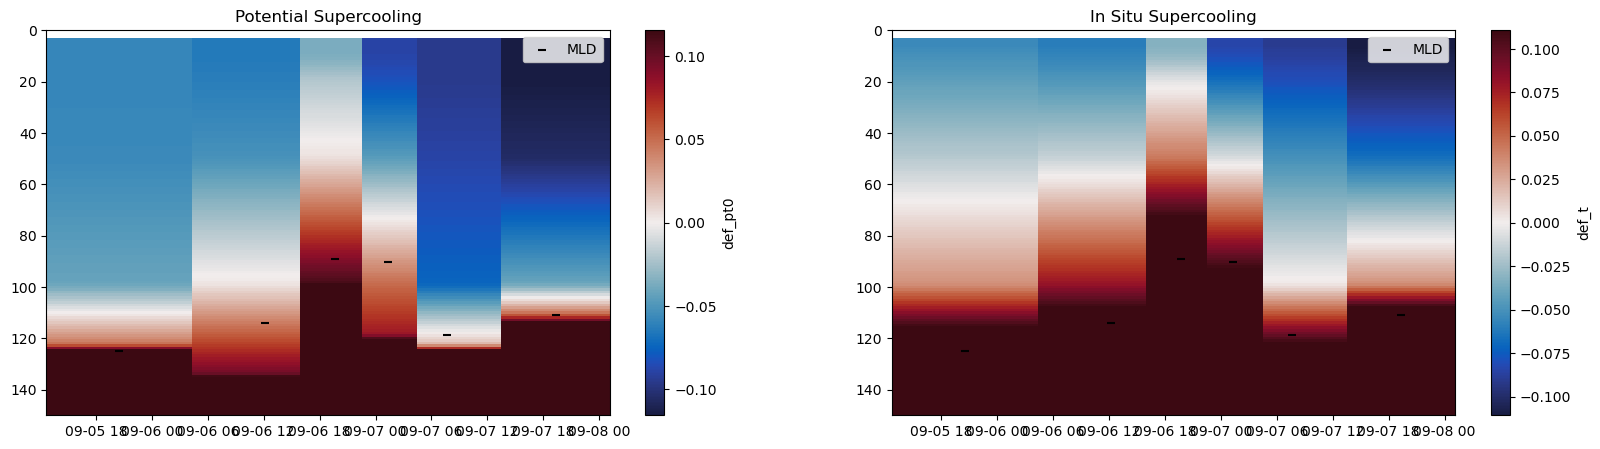

In [92]:
fig, ax = plt.subplots(1,2, figsize = (20,5))

depth = np.nan_to_num(cluster09_data2["dpth"], nan = 0)

# plot potential SC
max_SC = np.nanmin(cluster09_data2["def_pt0"])
pcm = ax[0].pcolormesh(cluster09_data2_datetimes, depth, cluster09_data2["def_pt0"], cmap = cmo.balance, vmin = max_SC, vmax = -max_SC)
# add MLD
ax[0].scatter(cluster09_data1["datetimes"], cluster09_data1["mld"], marker = "_", color = "black", label = "MLD")

# plot in situ SC
max_SC = np.nanmin(cluster09_data2["def_t"])
pcm_iS = ax[1].pcolormesh(cluster09_data2_datetimes, depth, cluster09_data2["def_t"], cmap = cmo.balance, vmin = max_SC, vmax = -max_SC)
# add MLD
ax[1].scatter(cluster09_data1["datetimes"], cluster09_data1["mld"], marker = "_", color = "black", label = "MLD")

ax[0].set_ylim(150,0)
ax[1].set_ylim(150,0)

ax[0].set_title("Potential Supercooling")
ax[1].set_title("In Situ Supercooling")

ax[0].legend(loc = "upper right")
ax[1].legend(loc = "upper right")

# make colorbar
fig.colorbar(pcm, label = "def_pt0")
fig.colorbar(pcm_iS, label = "def_t")


## ERA5 Conditions